# Coupled Electric Drives

Note: The example shown in this notebook is taken from the companion book [Nonlinear System Identification and Forecasting: Theory and Practice with SysIdentPy](https://sysidentpy.org/book/0-Preface/).

The CE8 coupled electric drives [dataset - Nonlinear Benchmark](https://www.nonlinearbenchmark.org/benchmarks) presents a compelling use case for demonstrating the performance of SysIdentPy. This system involves two electric motors driving a pulley with a flexible belt, creating a dynamic environment ideal for testing system identification tools.

> The [nonlinear benchmark website](https://www.nonlinearbenchmark.org/benchmarks) stands as a significant contribution to the system identification and machine learning community. The users are encouraged to explore all the papers referenced on the site.

### System Overview

The CE8 system, illustrated in Figure 1, features:
- **Two Electric Motors**: These motors independently control the tension and speed of the belt, providing symmetrical control around zero. This enables both clockwise and counterclockwise movements.
- **Pulley Mechanism**: The pulley is supported by a spring, introducing a lightly damped dynamic mode that adds complexity to the system.
- **Speed Control Focus**: The primary focus is on the speed control system. The pulley’s angular speed is measured using a pulse counter, which is insensitive to the direction of the velocity.

![](https://github.com/wilsonrljr/sysidentpy-data/blob/f38f95efb02194bf2ab116d63982305e2ec09213/book/assets/ce8_design.png?raw=true)
> Figure 1. CE8 system design.

### Sensor and Filtering

The measurement process involves:
- **Pulse Counter**: This sensor measures the angular speed of the pulley without regard to the direction.
- **Analogue Low Pass Filtering**: This reduces high-frequency noise, followed by antialiasing filtering to prepare the signal for digital processing. The dynamic effects are mainly influenced by the electric drive time constants and the spring, with the low pass filtering having a minimal impact on the output.

### SOTA Results

SysIdentPy can be used to build robust models for identifying and modeling the complex dynamics of the CE8 system. The performance will be compared against a benchmark provided by [Max D. Champneys, Gerben I. Beintema, Roland Tóth, Maarten Schoukens, and Timothy J. Rogers - Baselines for Nonlinear Benchmarks, Workshop on Nonlinear System Identification Benchmarks, 2024.](https://arxiv.org/pdf/2405.10779)


The benchmark evaluate the average metric between the two experiments. That's why the SOTA method do not have the better metric for `test 1`, but it is still the best overall.  The goal of this case study is not only to showcase the robustness of SysIdentPy but also provides valuable insights into its practical applications in real-world dynamic systems.

### Required Packages and Versions

This case study was verified with SysIdentPy 0.9.0 on Python 3.12.12 and
`nonlinear-benchmarks==1.0.1`. Install the repository checkout and the official
benchmark loader explicitly:

```bash
python -m pip install -e .
python -m pip install nonlinear-benchmarks==1.0.1
```

Use a virtual environment to isolate the optional loader. Numerical results
should be recomputed if the environment or model configuration changes.

### SysIdentPy configuration

In this section, we will demonstrate the application of SysIdentPy to the CE8 coupled electric drives dataset. This example showcases the robust performance of SysIdentPy in modeling and identifying complex dynamic systems. The following code will guide you through the process of loading the dataset, configuring the SysIdentPy parameters, and building a model for CE8 system.

This practical example will help users understand how to effectively utilize SysIdentPy for their own system identification tasks, leveraging its advanced features to handle the complexities of real-world dynamic systems. Let's dive into the code and explore the capabilities of SysIdentPy.


In [1]:
from warnings import catch_warnings, simplefilter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial, Fourier
from sysidentpy.utils.display_results import results
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.metrics import root_mean_squared_error
from sysidentpy.utils.plotting import plot_results

import nonlinear_benchmarks

ced_url = (
    "https://web.archive.org/web/20210117142533id_/"
    "http://www.it.uu.se/research/publications/reports/2010-020/NonlinearData.zip"
)
train_val, test = nonlinear_benchmarks.CED(url=ced_url, atleast_2d=True)
data_train_1, data_train_2 = train_val
data_test_1, data_test_2 = test

We used the `nonlinear_benchmarks` package to load the data. The user is referred to the package documentation [GerbenBeintema - nonlinear_benchmarks: The official data load for nonlinear benchmark datasets](https://github.com/GerbenBeintema/nonlinear_benchmarks/tree/master) to check the details of how to use it.

The following plot detail the training and testing data of both experiments. Here we are trying to get two models, one for each experiment, that have a better performance than the mentioned baselines.


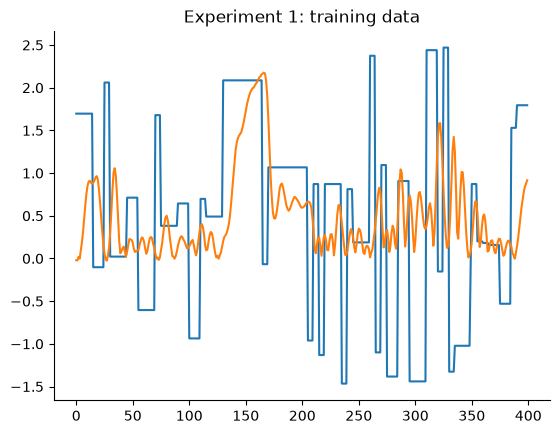

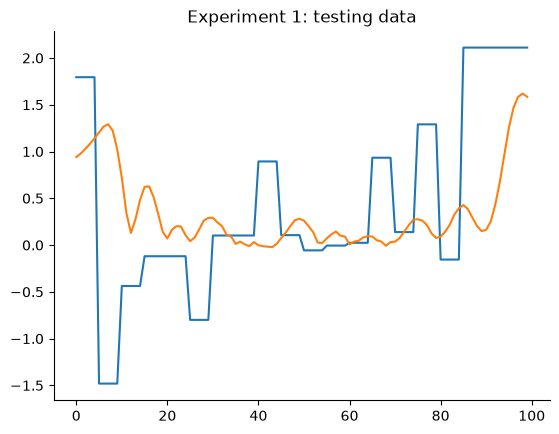

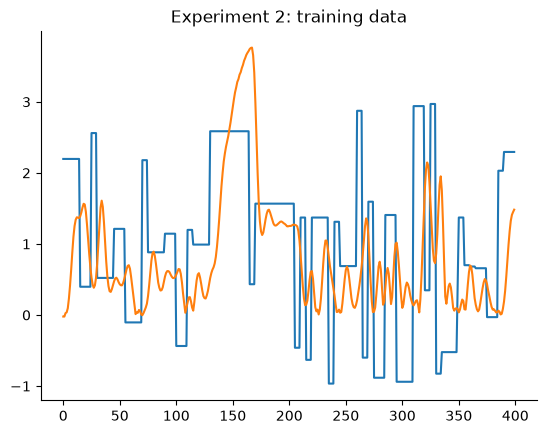

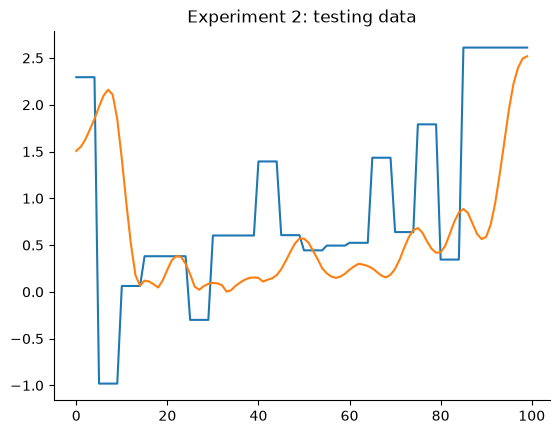

In [2]:
plt.plot(data_train_1.u)
plt.plot(data_train_1.y)
plt.title("Experiment 1: training data")
plt.show()

plt.plot(data_test_1.u)
plt.plot(data_test_1.y)
plt.title("Experiment 1: testing data")
plt.show()

plt.plot(data_train_2.u)
plt.plot(data_train_2.y)
plt.title("Experiment 2: training data")
plt.show()

plt.plot(data_test_2.u)
plt.plot(data_test_2.y)
plt.title("Experiment 2: testing data")
plt.show()

### Results

First, we will set the exactly same configuration to built models for both experiments. We can have better models by optimizing the configurations individually, but we will start simple.

A basic configuration of FROLS using a polynomial basis function with degree equal 2 is defined. The information criteria will be the default one, the `aic`. The `xlag` and `ylag` are set to $7$ in this first example.

Model for experiment 1:


RMSE: 0.102862


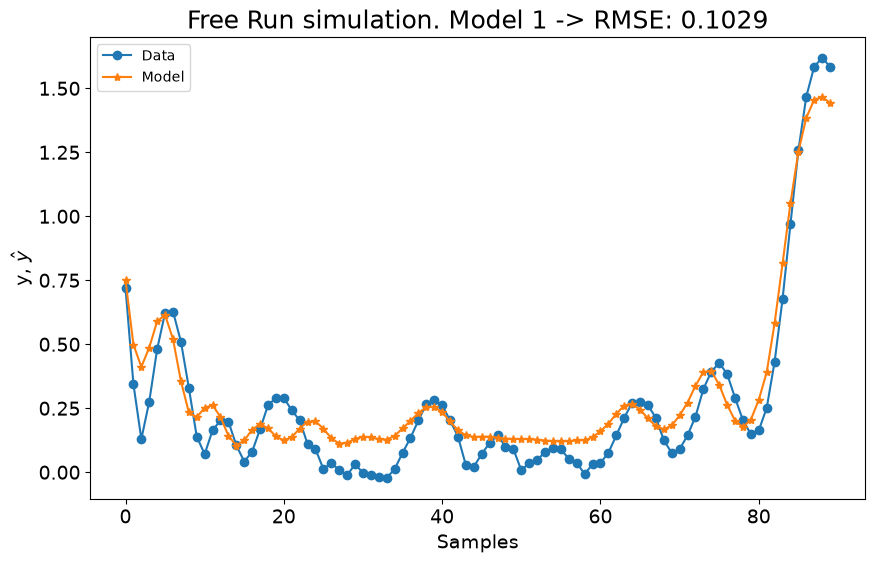

In [3]:
y_train = data_train_1.y
y_test = data_test_1.y
x_train = data_train_1.u
x_test = data_test_1.u

n = data_test_1.state_initialization_window_length

basis_function = Polynomial(degree=2)
model = FROLS(
    xlag=7,
    ylag=7,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aic",
    n_info_values=120,
)

with catch_warnings():
    simplefilter("ignore", UserWarning)
    model.fit(X=x_train, y=y_train)
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]
rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")
plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 1 -> RMSE: {round(rmse, 4)}",
)

Model for experiment 2:


RMSE: 0.106816


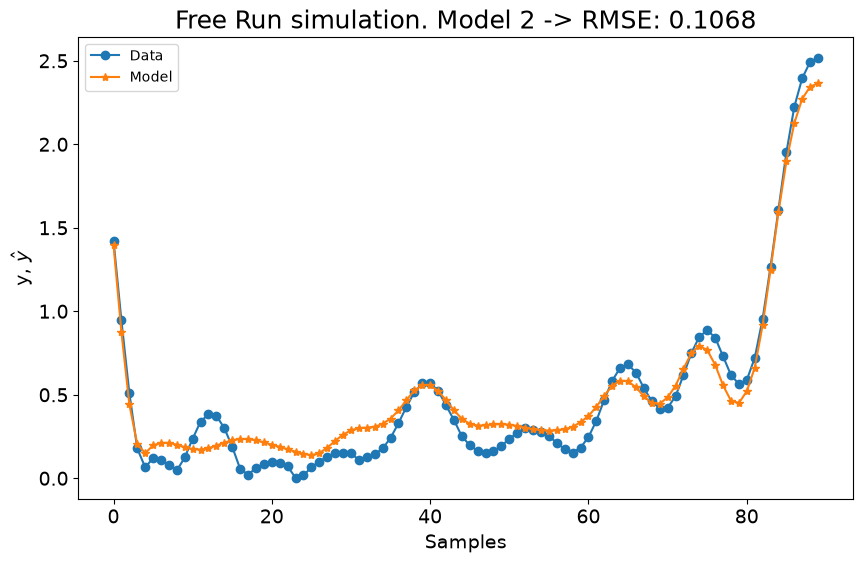

In [4]:
y_train = data_train_2.y
y_test = data_test_2.y
x_train = data_train_2.u
x_test = data_test_2.u

n = data_test_2.state_initialization_window_length

basis_function = Polynomial(degree=2)
model = FROLS(
    xlag=7,
    ylag=7,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aic",
    n_info_values=120,
)

with catch_warnings():
    simplefilter("ignore", UserWarning)
    model.fit(X=x_train, y=y_train)
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]
rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")
plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 2 -> RMSE: {round(rmse, 4)}",
)

![](https://github.com/wilsonrljr/sysidentpy-data/blob/f38f95efb02194bf2ab116d63982305e2ec09213/book/assets/ce8_sota.png?raw=true)

With the current loader and the benchmark-defined initialization window, this
first configuration gives RMSE $0.102862$ for experiment 1 and $0.106816$ for
experiment 2. Their average is $0.104839$. The samples reserved for state
initialization are excluded once, and the recursion starts from the last
`model.max_lag` outputs inside that window.

The external table is still useful as context, but its values should only be
compared after matching the split, initialization, normalization and aggregation
rules. We will therefore use the present RMSE values to compare the SysIdentPy
configurations with one another. Before increasing the lags, the information
criterion is shown:


Text(0, 0.5, 'Information Criteria')

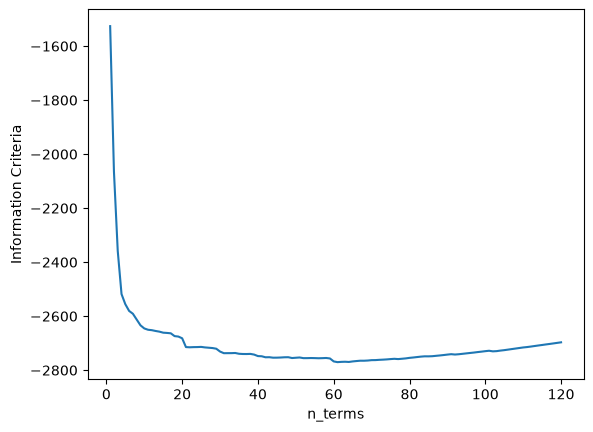

In [5]:
xaxis = np.arange(1, model.n_info_values + 1)
plt.plot(xaxis, model.info_values)
plt.xlabel("n_terms")
plt.ylabel("Information Criteria")

It can be observed that after 22 regressors, adding new regressors do not improve the model performance (considering the configuration defined for that model). Because we want to try models with higher lags and higher nonlinearity degree, the stopping criteria will be changed to `err_tol` instead of information criteria. This will made the algorithm runs considerably faster.


(22, 2) 0.9971197764554547
RMSE: 0.110933


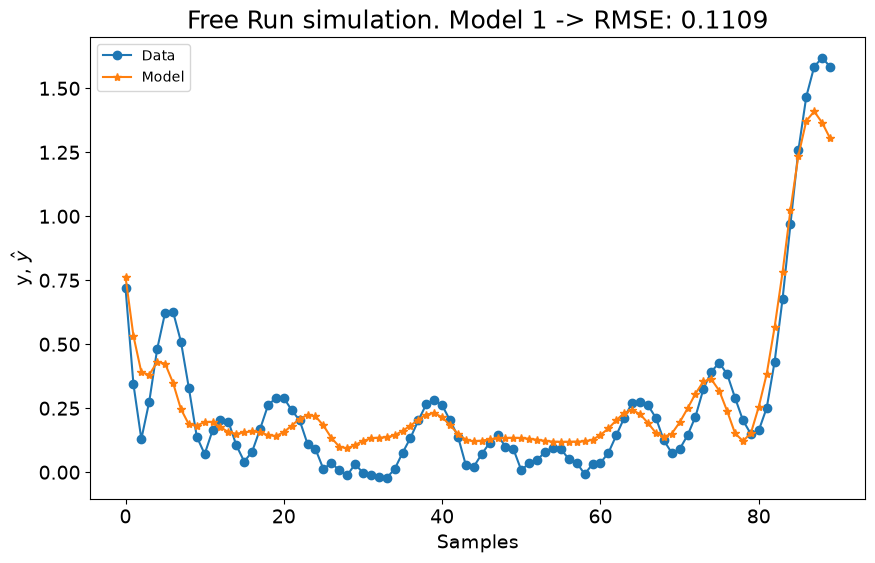

In [6]:
# experiment 1
y_train = data_train_1.y
y_test = data_test_1.y
x_train = data_train_1.u
x_test = data_test_1.u

n = data_test_1.state_initialization_window_length

basis_function = Polynomial(degree=2)
model = FROLS(
    xlag=10,
    ylag=10,
    basis_function=basis_function,
    estimator=LeastSquares(),
    err_tol=0.9996,
    n_terms=22,
    order_selection=False,
)

model.fit(X=x_train, y=y_train)
print(model.final_model.shape, model.err.sum())
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]

rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")

plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 1 -> RMSE: {round(rmse, 4)}",
)

RMSE: 0.107076


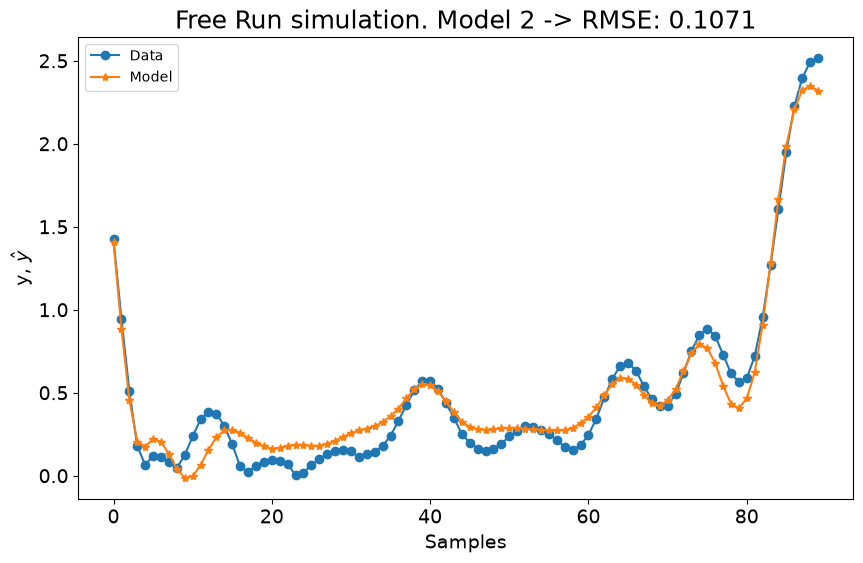

In [7]:
# experiment 2
y_train = data_train_2.y
y_test = data_test_2.y
x_train = data_train_2.u
x_test = data_test_2.u

n = data_test_2.state_initialization_window_length

basis_function = Polynomial(degree=2)
model = FROLS(
    xlag=10,
    ylag=10,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aicc",
    err_tol=0.9996,
    n_terms=22,
    order_selection=False,
)

model.fit(X=x_train, y=y_train)
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]

rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")

plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 2 -> RMSE: {round(rmse, 4)}",
)

The 10-lag, 22-term models give RMSE $0.110933$ and $0.107076$ for experiments
1 and 2, respectively. The official state-initialization window contains 10
samples, so the former 14-lag configurations are not valid under this protocol.
Increasing the lag to the largest valid value does not improve this degree-2
configuration. Therefore, let's set the polynomial degree to $3$ and increase
the number of terms to `n_terms=40` if the `err_tol` is not reached. These values
are empirical; the estimator, error tolerance, structure-selection algorithm and
basis function are other possible tuning dimensions.


(40, 3) 0.9984715085784007
RMSE: 0.112503


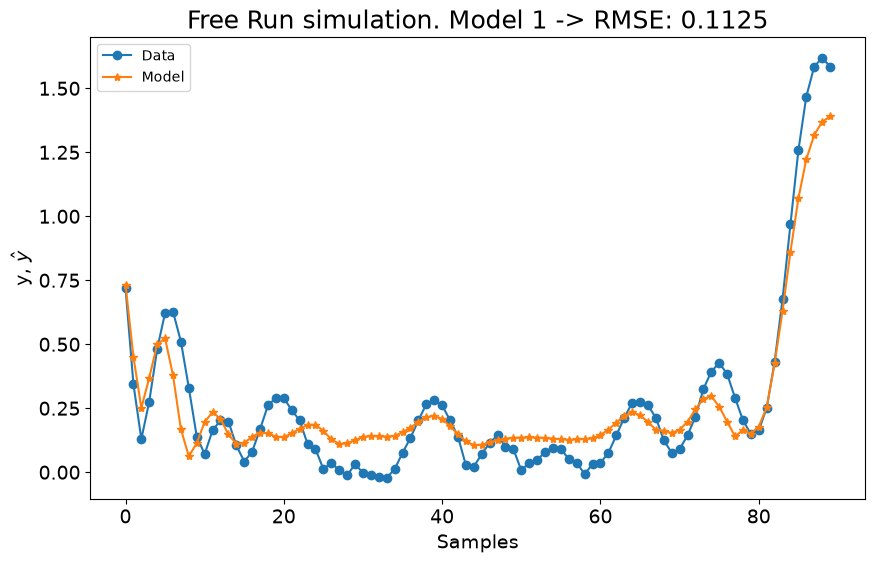

In [8]:
# experiment 1
y_train = data_train_1.y
y_test = data_test_1.y
x_train = data_train_1.u
x_test = data_test_1.u

n = data_test_1.state_initialization_window_length

basis_function = Polynomial(degree=3)
model = FROLS(
    xlag=10,
    ylag=10,
    basis_function=basis_function,
    estimator=LeastSquares(),
    err_tol=0.9996,
    n_terms=40,
    order_selection=False,
)

model.fit(X=x_train, y=y_train)
print(model.final_model.shape, model.err.sum())
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]

rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")

plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 1 -> RMSE: {round(rmse, 4)}",
)

RMSE: 0.096002


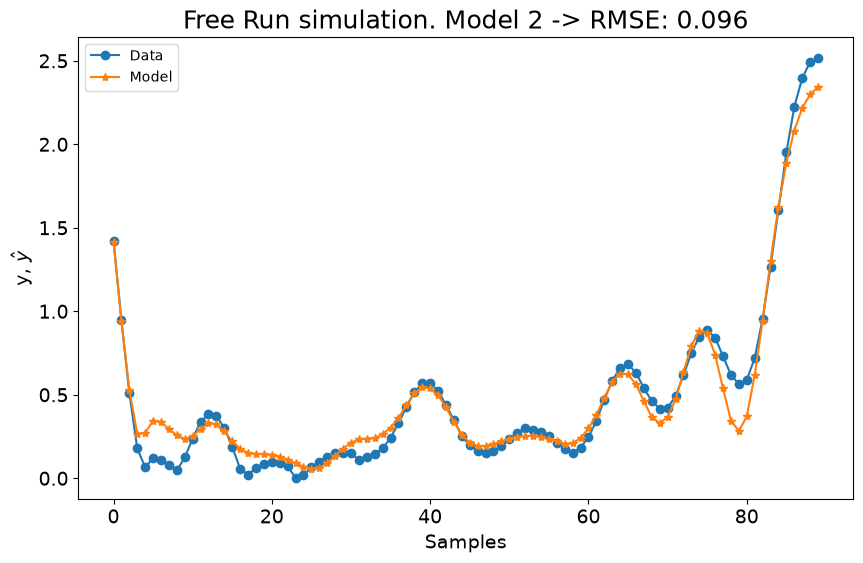

In [9]:
# experiment 2
y_train = data_train_2.y
y_test = data_test_2.y
x_train = data_train_2.u
x_test = data_test_2.u

n = data_test_2.state_initialization_window_length

basis_function = Polynomial(degree=3)
model = FROLS(
    xlag=10,
    ylag=10,
    basis_function=basis_function,
    estimator=LeastSquares(),
    info_criteria="aicc",
    err_tol=0.9996,
    n_terms=40,
    order_selection=False,
)

model.fit(X=x_train, y=y_train)
if model.max_lag > n:
    raise ValueError("The model lag exceeds the benchmark initialization window.")
start = n - model.max_lag
yhat = model.predict(X=x_test[start:], y=y_test[start:n])
yhat = yhat[model.max_lag :]

rmse = root_mean_squared_error(y_test[n:], yhat)
print(f"RMSE: {rmse:.6f}")

plot_results(
    y=y_test[n:],
    yhat=yhat,
    n=10000,
    title=f"Free Run simulation. Model 2 -> RMSE: {round(rmse, 4)}",
)

The degree-3 models give RMSE $0.112503$ and $0.096002$, with an average of
$0.104253$. The second experiment improves, whereas the first does not. This is
why the two experiments should be reported separately and why the external SOTA
table is not used to claim a ranking without an identical evaluation protocol.
